In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from operator import itemgetter
from sklearn.neighbors import NearestNeighbors, KDTree

In [2]:
df = pd.read_csv('./iris.csv')
cols = df.columns[:-1]

In [3]:
# sns.pairplot(data=df, hue='variety')

In [4]:
X = df.iloc[:, :-1]

### **OPTIMAL VALUE FOR EPSILON**

In [5]:
# https://towardsdatascience.com/machine-learning-clustering-dbscan-determine-the-optimal-value-for-epsilon-eps-python-example-3100091cfbc
# http://www.sefidian.com/2020/12/18/how-to-determine-epsilon-and-minpts-parameters-of-dbscan-clustering/
neight = NearestNeighbors(n_neighbors=2)
nbrs = neight.fit(X)

distances, indices = nbrs.kneighbors(X)

In [6]:
distances = np.sort(distances, axis=0)
d = distances[:,1]

In [7]:
eps_op = -1
for i in range(1, len(d)):
    rate = d[i] - d[i-1]
    if  rate > eps_op:
        eps_op = rate
        x = i
eps_op

0.10239139080127757

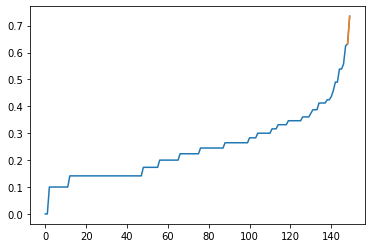

In [8]:
plt.clf()
plt.plot(d)     # linestyle="", marker='o', alpha=0.8, markersize=2
plt.plot([x-1, x], [d[x-1], d[x]])

In [9]:
print(f'median: {np.median(d)}')
print(f'mean: {np.mean(d)}')
# eps_op = np.mean([np.median(d), eps_op])
eps_op = np.mean(d)

median: 0.22360679774997935
mean: 0.24710674026810603


## **DBSCAN**

In [10]:
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'w']
p1 = ('petal.width', 'petal.length')
p2 = ('petal.length', 'sepal.width')
p3 = ('sepal.length', 'petal.width')
UNDEFINED = 'gray'
NOISE = 'orange'

In [11]:
class DBScan():
    def __init__(self, data, eps, treshold, m='manhattan'):
        self.data = data
        self.KDT = KDTree(data.to_numpy(), metric=m)
        self.e = eps
        self.t = treshold

        self.label = [UNDEFINED for _ in range(len(data))]
    
    def algorithm(self, d, c_label):
        for i in range(len(d)):
            if (self.label[i] != UNDEFINED):
                continue
            p = d.iloc[i].to_numpy()
            N = self.KDT.query_radius([p], r=self.e)[0]
            # print(N, len(N), i)
            
            if len(N) < self.t:
                self.label[i] = NOISE
                continue
            c = c_label + 1
            self.label[i] = colors[c]

            S = np.delete(N, np.where(N==i))

            # print(S, len(S), i)
            
            j = 0
            lS = len(S)
            while j < lS:
                # print(j, len(S), S)
                idx = S[j]
                p_ = d.iloc[idx].to_numpy()
                
                if self.label[idx] == NOISE:
                    self.label[idx] = colors[c]
                if (self.label[idx] != UNDEFINED):
                    j+=1
                    continue
                
                N_ = self.KDT.query_radius([p_], r=self.e)[0]
                self.label[idx] = colors[c]
                # print('\t', N_)

                if len(N_) < self.t:
                    j+=1
                    continue
                N_ = np.array([nn for nn in N_ if nn not in S])
                # print('\t', N_)

                S = np.concatenate((S, N_), axis=None).astype(int)
                lS = len(S)
                j+=1
            self.save_plot(p1)
            # self.save_plot(p2)
            # self.save_plot(p3)
            

    def execute(self):
        # display(self.data)
        self.algorithm(self.data, 0)
        print(self.label)
        
    def save_plot(self, xy):
        x, y = xy
        plt.clf()
        for _ in range(len(self.data)):
            row = self.data.iloc[_]
            plt.scatter(
                row[x], row[y], 
                c=self.label[_], alpha=.9
                )   # linestyle="", marker='o', edgecolors='black'
        plt.show()


In [12]:
data = df.copy()
d = data.iloc[:,:-1]
r, dim = d.shape

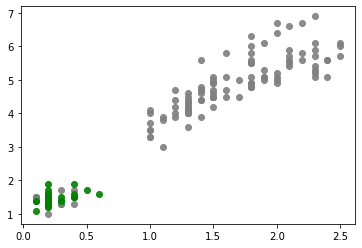

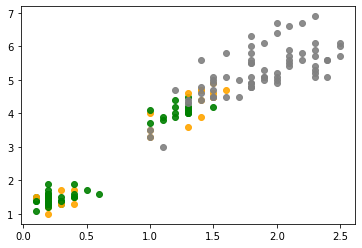

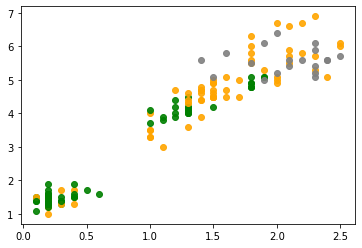

['g', 'g', 'g', 'g', 'g', 'orange', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'orange', 'orange', 'orange', 'g', 'orange', 'g', 'g', 'g', 'orange', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'orange', 'orange', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'orange', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'orange', 'orange', 'orange', 'g', 'orange', 'g', 'orange', 'orange', 'orange', 'orange', 'orange', 'g', 'orange', 'orange', 'orange', 'orange', 'orange', 'g', 'orange', 'g', 'g', 'g', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'g', 'g', 'g', 'orange', 'orange', 'orange', 'orange', 'orange', 'g', 'g', 'g', 'orange', 'g', 'orange', 'g', 'g', 'g', 'orange', 'orange', 'g', 'orange', 'g', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'orange', 'g', 'orange', 'orange', 'g', 'g', 'orange', 'orange', 'orange', 'ora

In [13]:
dbs = DBScan(data=d, eps=0.55, treshold=1.5*dim)
dbs.execute()

In [14]:
# dbs.save_plot(p1)
# dbs.save_plot(p2)